# EVALUATE

## Importok

In [1]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

from sklearn.inspection import permutation_importance

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import shap

## Load model

In [2]:
MODEL_PATH = "../models/model.pkl"
FEATURES_PATH = "../artifacts/features.pkl"
LOCATION_MAPPING_PATH = "../artifacts/location_mapping.pkl"

model = joblib.load(MODEL_PATH)
FEATURES = joblib.load(FEATURES_PATH)
LOCATION_MAPPING = joblib.load(LOCATION_MAPPING_PATH)
print("Model loaded: ", MODEL_PATH)

Model loaded:  ../models/model.pkl


## Load data

In [3]:
train = pd.read_parquet("../data/preprocessed/train.parquet")
test  = pd.read_parquet("../data/preprocessed/test.parquet")

print("Dataset loaded:", train.shape)


Dataset loaded: (52623, 38)


## Target létrehozás

In [4]:
train = train.sort_values(["location", train.index.name])
test  = test.sort_values(["location", test.index.name])

train["pm25_next"] = train.groupby("location")["pm25"].shift(-1)
test["pm25_next"]  = test.groupby("location")["pm25"].shift(-1)

TARGET = "pm25_next"

## NAN-ok törlése

In [5]:
columns = [
    "pm25_next",
    "pm25_lag1",
    "pm25_lag3",
    "pm25_lag6",
    "pm25_lag24",
    "pm25_roll6",
    "pm25_roll24",
    "pm25_trend_3h",
    "pm25_std_12h",
    "temp_change_3h",
    "humidity_change_3h",
    "wind_change_3h",
    "stagnation_hours_6h"
]

train = train.dropna(subset=columns)
test  = test.dropna(subset=columns)

## Train és teszt adatok létrehozása

In [6]:
X_test = test[FEATURES]
y_test = test["pm25_next"]

# y_pred_log = model.predict(X_test)
# y_pred = np.maximum(0, np.expm1(y_pred_log))

if isinstance(model, dict):  # ensemble
    preds = []
    for m in model.values():
        p_log = m.predict(X_test)
        p = np.maximum(0, np.expm1(p_log))
        preds.append(p)
    y_pred = np.mean(preds, axis=0)
else:
    y_pred_log = model.predict(X_test)
    y_pred = np.maximum(0, np.expm1(y_pred_log))


## 1-step sanity validation

In [7]:
# --- MAE ---
mae = mean_absolute_error(y_test, y_pred)

# --- RMSE ---
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# --- R² ---
r2 = r2_score(y_test, y_pred)

# --- MAPE ---
mape = mean_absolute_percentage_error(y_test, y_pred)

# --- SMAPE ---
smape = np.mean(
    2 * np.abs(y_pred - y_test) /
    (np.abs(y_test) + np.abs(y_pred) + 1e-6)
)

# --- MASE ---
naive_pred = test["pm25_lag1"]

valid = naive_pred.notna()

naive_mae = mean_absolute_error(
    y_test[valid],
    naive_pred[valid]
)

mase = mae / naive_mae

print("\nValidation results")
print("1-step MAE:", round(mae, 3), "µg/m³")
print("RMSE :", round(rmse,3))
print("MAPE :", round(mape,3))
print("SMAPE:", round(smape,3))
print("MASE :", round(mase,3))
print("R2   :", round(r2,3))


Validation results
1-step MAE: 3.595 µg/m³
RMSE : 5.88
MAPE : 0.215
SMAPE: 0.198
MASE : 0.715
R2   : 0.887


## Validation metrics

### Predikció vs valós érték scatter
Megmutatja mennyire közel van a modell az ideálishoz.

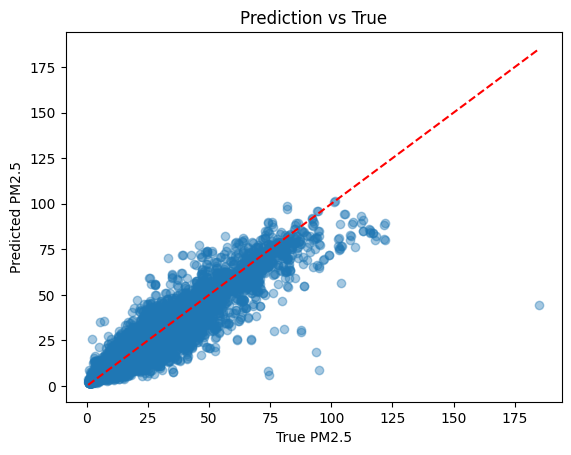

In [8]:
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--")
plt.xlabel("True PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Prediction vs True")
plt.show()

### Hiba (residual) eloszlás
ideális ha közép ≈ 0 szimmetrikus
Megmutatja a modell biasát.

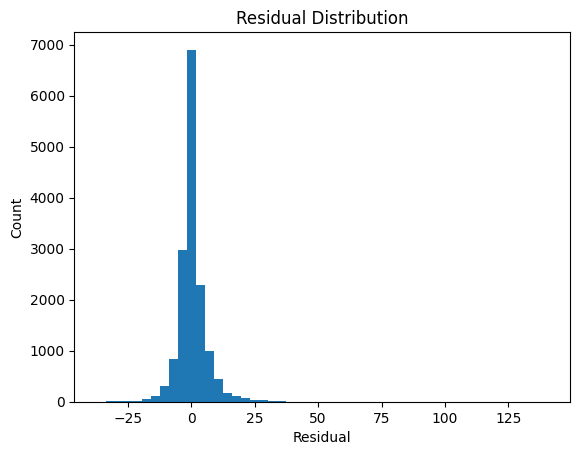

In [9]:
residuals = y_test - y_pred

plt.figure()
plt.hist(residuals, bins=50)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.show()

### Residual vs prediction plot
Ha tölcsér alakú → heteroszkedaszticitás.
Outliereket mutat.


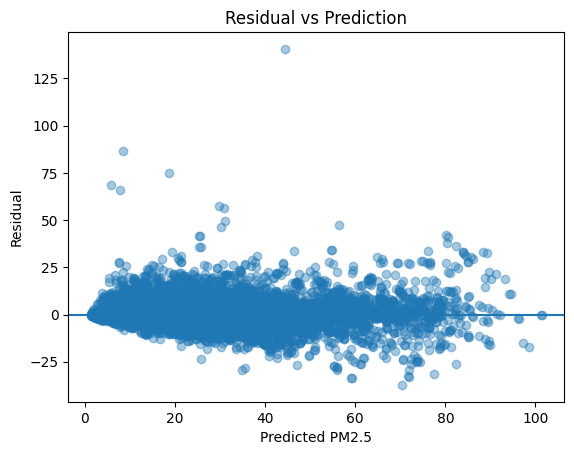

In [10]:
plt.figure()
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0)
plt.xlabel("Predicted PM2.5")
plt.ylabel("Residual")
plt.title("Residual vs Prediction")
plt.show()

### Idősoros predikció grafikon
spike detection, lag, drift

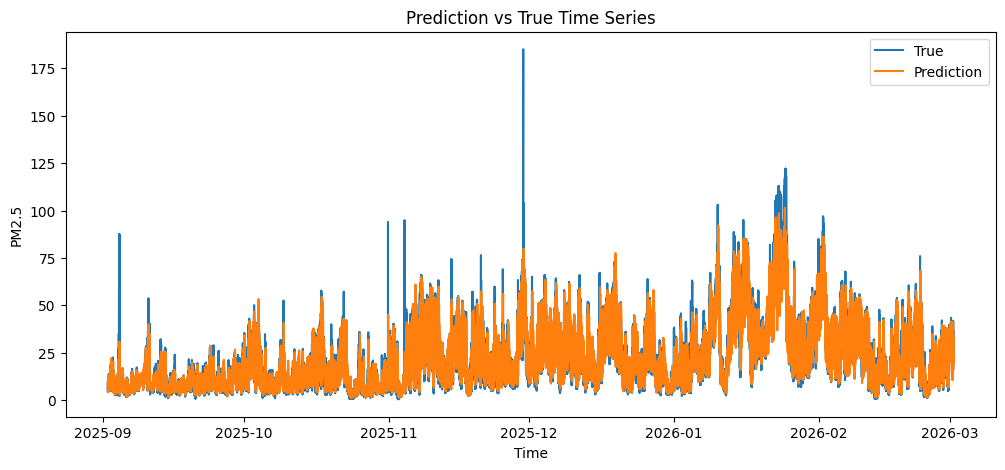

In [11]:
plt.figure(figsize=(12,5))
plt.plot(y_test.sort_index(), label="True")
plt.plot(pd.Series(y_pred, index=y_test.index).sort_index(), label="Prediction")
plt.legend()
plt.title("Prediction vs True Time Series")
plt.xlabel("Time")
plt.ylabel("PM2.5")
plt.show()


### Feature permutation importance grafikon

A permutation importance elemzést csak az ensemble egyik komponens modelljén végeztük el.

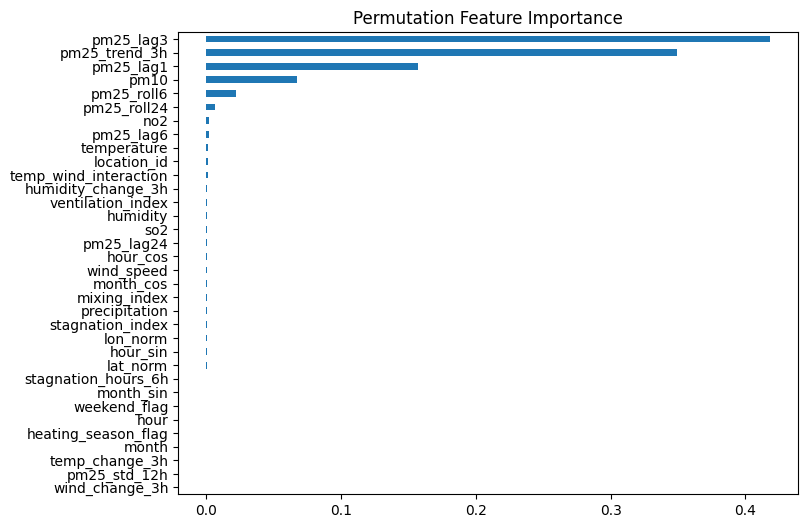

In [12]:
y_test_log = np.log1p(y_test)

# --- ensemble eset kezelése ---
if isinstance(model, dict):
    model_for_perm = model["LGBM"]
else:
    model_for_perm = model

result = permutation_importance(
    model_for_perm,
    X_test,
    y_test_log,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance = pd.Series(
    result.importances_mean,
    index=FEATURES
).sort_values()

plt.figure(figsize=(8,6))
importance.plot.barh()
plt.title("Permutation Feature Importance")
plt.show()

### Hiba vs idő

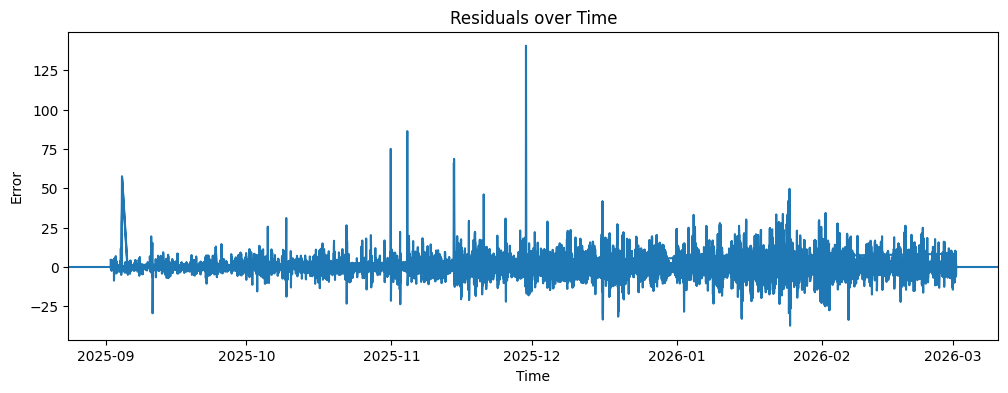

In [13]:
plt.figure(figsize=(12,4))
plt.plot(y_test.index, residuals)
plt.axhline(0)
plt.title("Residuals over Time")
plt.xlabel("Time")
plt.ylabel("Error")
plt.show()

### Hiba vs érték

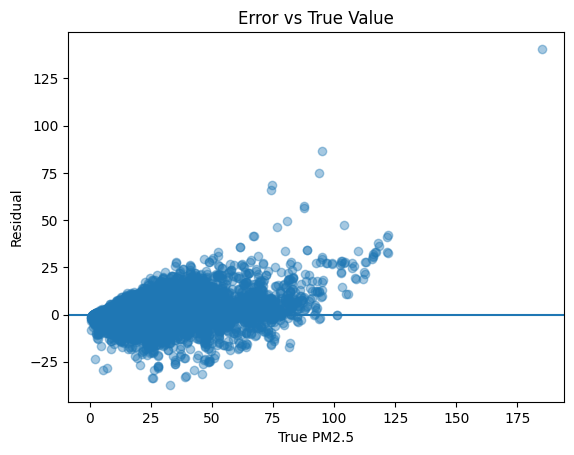

In [14]:
plt.figure()
plt.scatter(y_test, residuals, alpha=0.4)
plt.axhline(0)
plt.xlabel("True PM2.5")
plt.ylabel("Residual")
plt.title("Error vs True Value")
plt.show()

### SHAP ANALYSIS

SHAP-hoz az ensemble egyik komponensét használjuk


Running SHAP analysis...


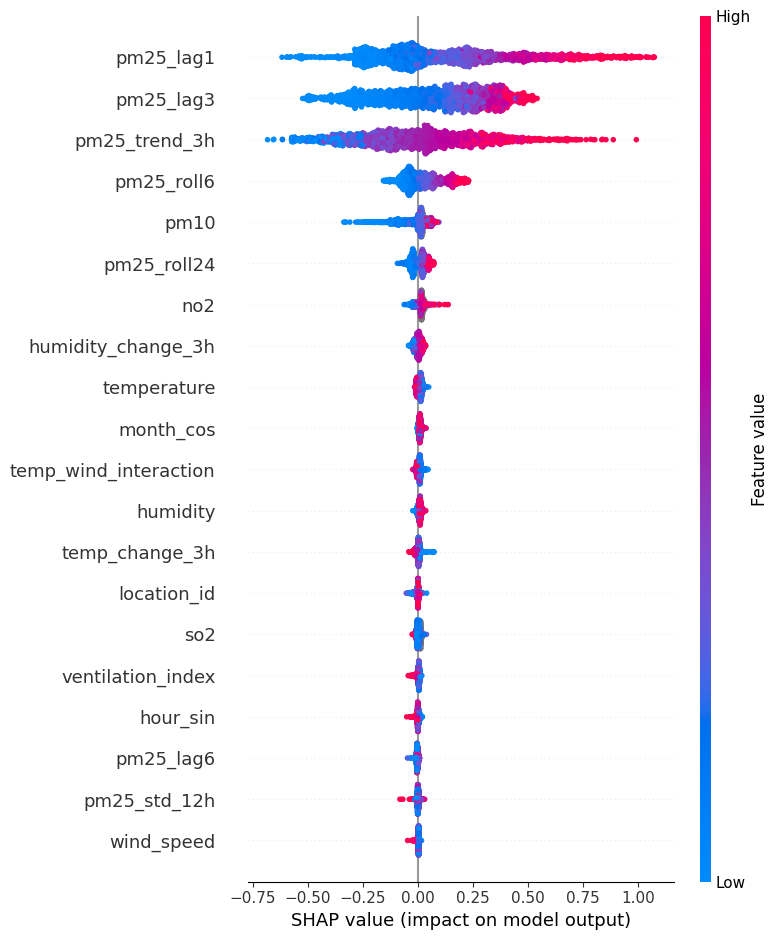

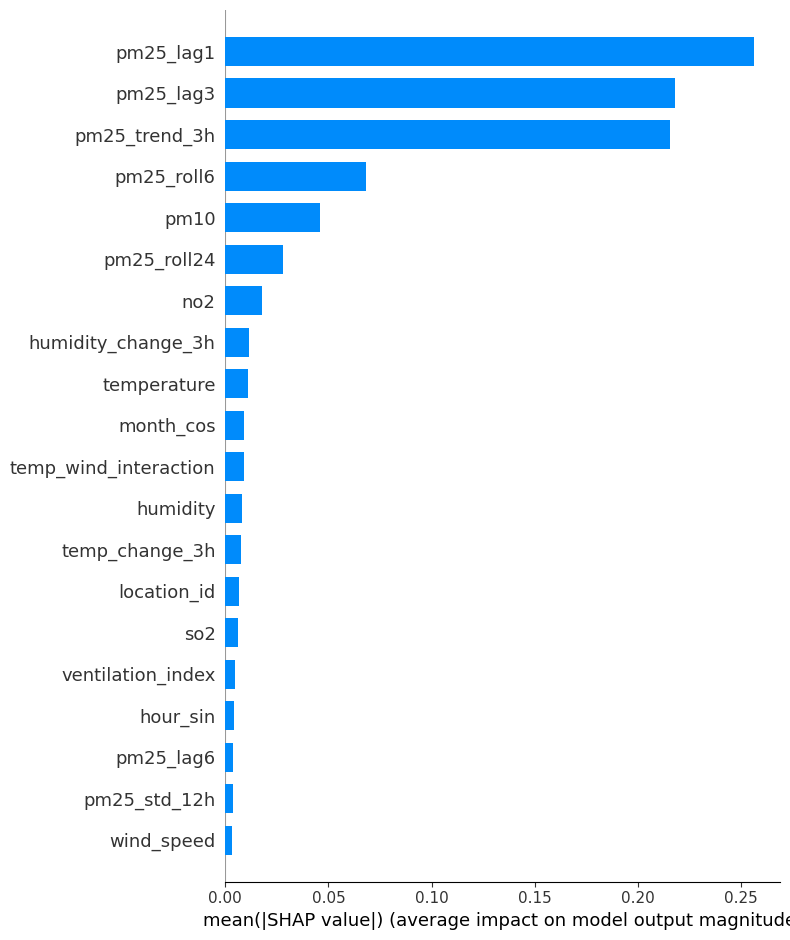


Top features (SHAP):
pm25_lag1             0.256210
pm25_lag3             0.218315
pm25_trend_3h         0.215733
pm25_roll6            0.068182
pm10                  0.045811
pm25_roll24           0.027888
no2                   0.017878
humidity_change_3h    0.011643
temperature           0.010760
month_cos             0.008914
dtype: float64


In [15]:
print("\nRunning SHAP analysis...")

if isinstance(model, dict):
    model_for_shap = model["LGBM"].named_steps["model"]
elif hasattr(model, "named_steps"):
    model_for_shap = model.named_steps["model"]
else:
    model_for_shap = model

X_sample = X_test.sample(min(2000, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(model_for_shap)
shap_values = explainer.shap_values(X_sample)

# ============================================================
# 5.1. SUMMARY PLOT
# ============================================================

shap.summary_plot(shap_values, X_sample)

# ============================================================
# 5.2. FEATURE IMPORTANCE (bar)
# ============================================================

shap.summary_plot(shap_values, X_sample, plot_type="bar")

# ============================================================
# 5.3. TOP FEATURE AUTOMATIKUSAN
# ============================================================

shap_importance = np.abs(shap_values).mean(axis=0)
feat_imp = pd.Series(shap_importance, index=X_sample.columns).sort_values(ascending=False)

print("\nTop features (SHAP):")
print(feat_imp.head(10))

# TOP 10 mentéshez
top_features = feat_imp.head(10).to_dict()


## Save metrics

In [16]:
metrics = {
    "MAE": mae,
    "RMSE": rmse,
    "MAPE": mape,
    "SMAPE": smape,
    "MASE": mase,
    "R2": r2,
    "top_features": top_features
}

pd.Series(metrics).to_json("../models/evaluation.json")

print("Metrics saved to ../models/evaluation.json")

Metrics saved to ../models/evaluation.json


## Összegzés

A modell (ensemble) jó általános teljesítményt mutat, alacsony MAE és magas R² értékekkel. A predikciók jól követik az idősoros mintázatokat, és a modell stabilan generalizál a teszt adatokon.

A hibaeloszlás közel szimmetrikus, ami alacsony bias-ra utal, azonban a nagyobb PM2.5 értékeknél a modell hajlamos alulbecslésre. Ez a residual plotokon és az idősoros grafikonokon is megfigyelhető.

A permutation importance és SHAP elemzés alapján a modell döntően a múltbeli PM2.5 értékekre támaszkodik (lag feature-ök), míg az időjárási változók kisebb szerepet játszanak.

Összességében a modell jól működik a normál tartományban, azonban az extrém szennyezési események predikciója tovább fejleszthető.